<a href="https://colab.research.google.com/github/Ede-Rojin-Delibas/Machine-Learning/blob/master/Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#UNDERSTANDING DATA & EDA

#understanding the structure of the data
import pandas as pd
df= pd.read_csv('/content/churn_analysis.csv')
df.shape

(7043, 21)

In [ ]:
df.head(25)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


<Axes: xlabel='Churn', ylabel='count'>

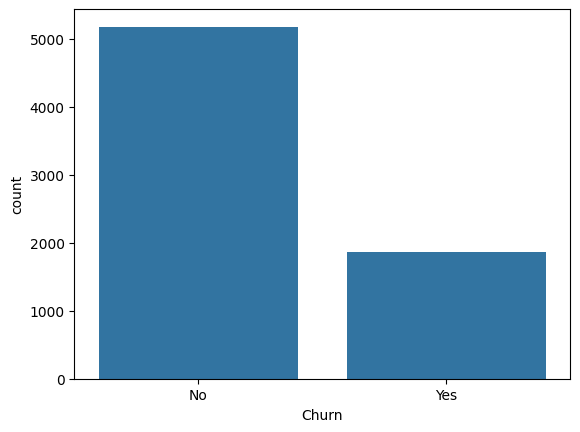

In [ ]:
import seaborn as sns
sns.countplot(x='Churn',data=df)

In [ ]:
#Data Quality Check
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# data types problems
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
#discover numerical attributes
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>, <Axes: >]],
      dtype=object)

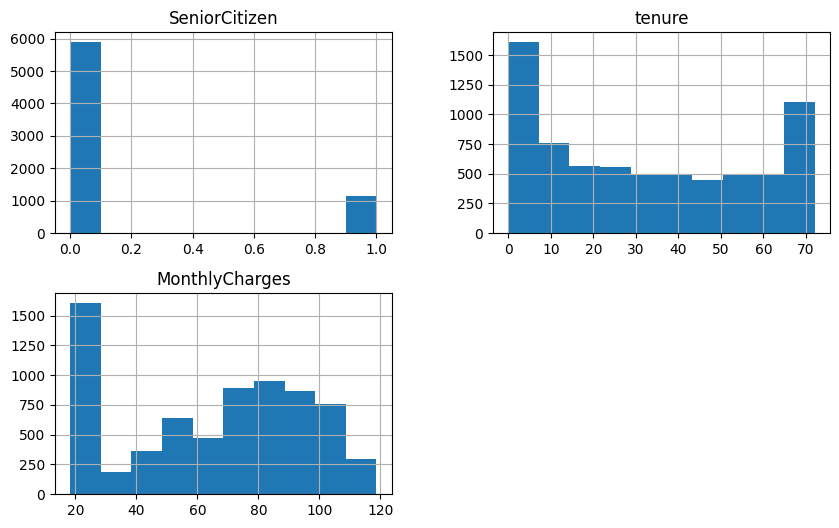

In [ ]:
df.hist(figsize=(10,6))

In [ ]:
#discovering categorical attributes
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


<Axes: xlabel='Churn', ylabel='tenure'>

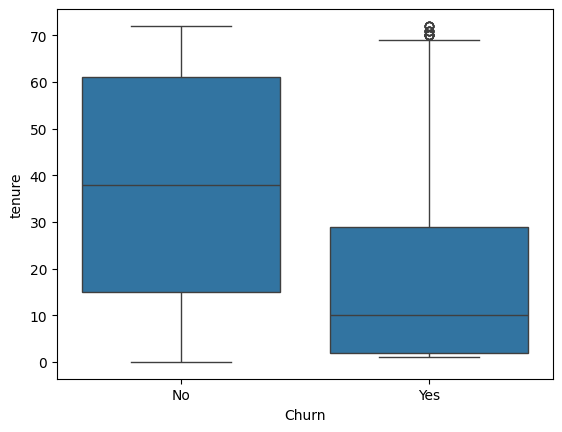

In [ ]:
#Relations with our target
##tenure vs churn
sns.boxplot(x='Churn',y='tenure',data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

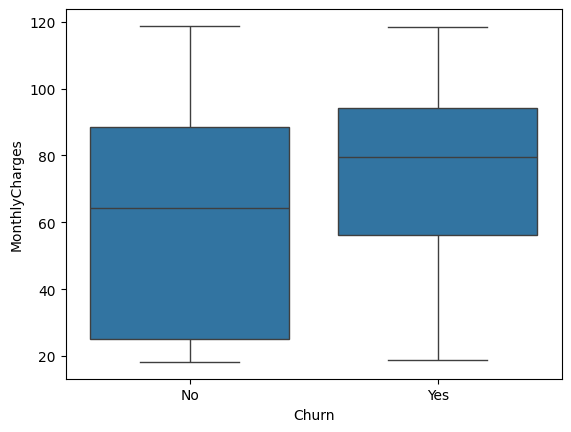

In [ ]:
##monthly charges vs churn
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

<Axes: xlabel='Contract', ylabel='count'>

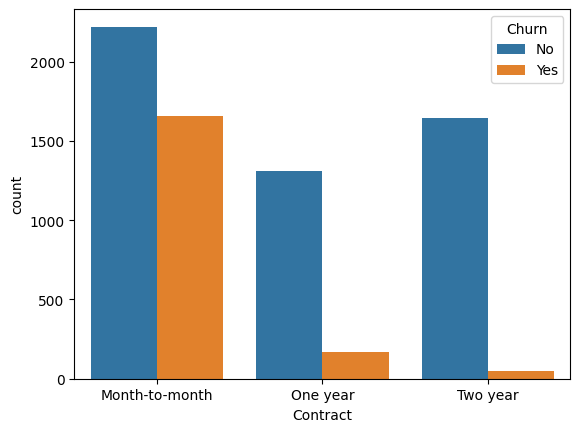

In [ ]:
##contract vs churn
sns.countplot(x='Contract',hue='Churn',data=df)

In [ ]:
#frequency distribution
df['TechSupport'].value_counts()

,count
TechSupport,
No,3473
Yes,2044
No internet service,1526


In [ ]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


In [ ]:
#Seeing the ratio by normalization
df['InternetService'].value_counts(normalize=True) * 100

,proportion
InternetService,
Fiber optic,43.958540
DSL,34.374556
No,21.666903


<Axes: xlabel='TechSupport', ylabel='count'>

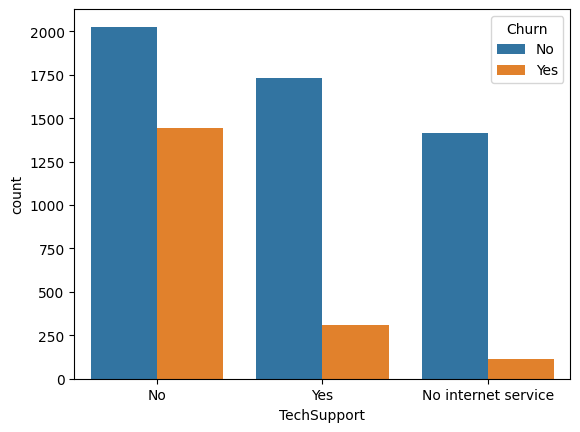

In [ ]:
#tech support vs churn
sns.countplot(x='TechSupport',hue='Churn',data=df)

<Axes: xlabel='InternetService', ylabel='count'>

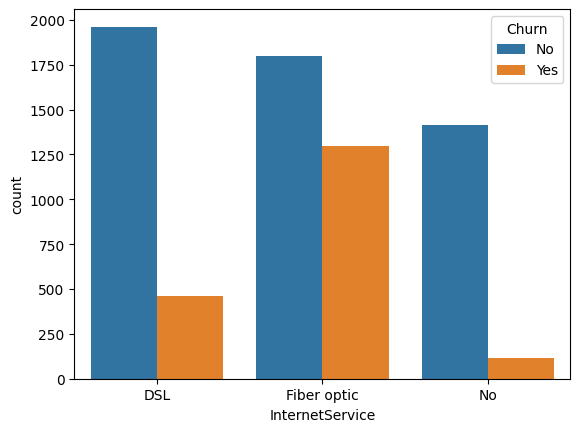

In [ ]:
#Internet service vs churn
sns.countplot(x='InternetService',hue='Churn',data=df)

In [ ]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


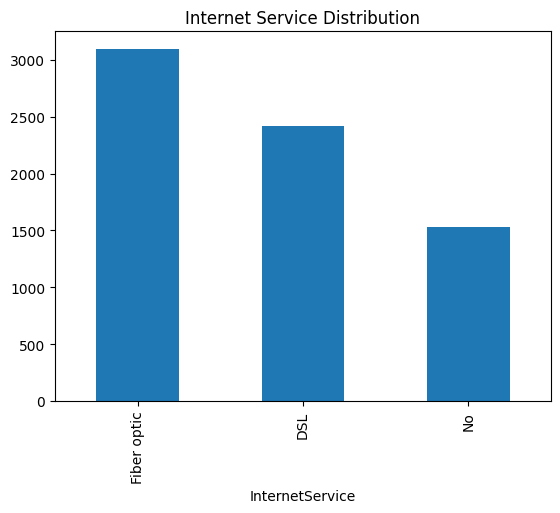

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
df['InternetService'].value_counts().plot(kind='bar')
plt.title('Internet Service Distribution')
plt.show()

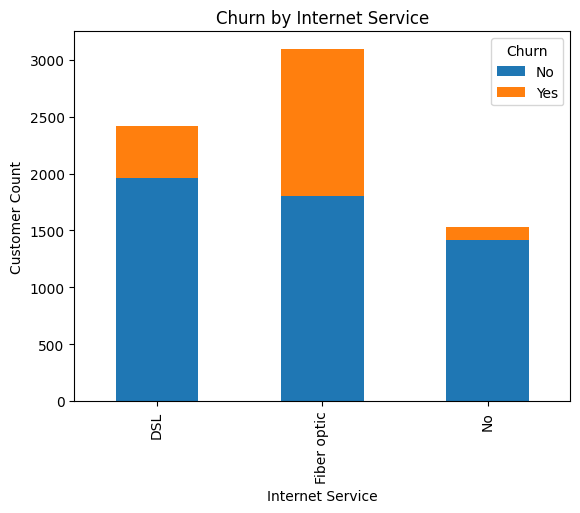

In [ ]:
pd.crosstab(df['InternetService'],df['Churn']).plot(kind='bar',stacked=True)
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Customer Count')
plt.show()

Text(0, 0.5, 'Rate')

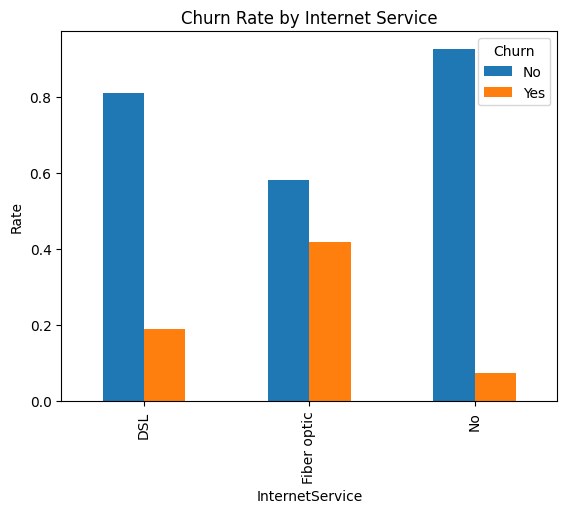

In [ ]:
#visualizing directly the Churn
churn_rate=pd.crosstab(df['InternetService'],df['Churn'],normalize='index')
churn_rate.plot(kind='bar')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Rate')

In [ ]:
#Investigating all categorical attributes automatically
categorical_cols=df.select_dtypes(include='object').columns
for col in categorical_cols:
  print(f"\n--- {col} ---")
  print(pd.crosstab(df[col],df['Churn'],normalize='index') * 100)


--- customerID ---
Churn          No    Yes
customerID              
0002-ORFBO  100.0    0.0
0003-MKNFE  100.0    0.0
0004-TLHLJ    0.0  100.0
0011-IGKFF    0.0  100.0
0013-EXCHZ    0.0  100.0
...           ...    ...
9987-LUTYD  100.0    0.0
9992-RRAMN    0.0  100.0
9992-UJOEL  100.0    0.0
9993-LHIEB  100.0    0.0
9995-HOTOH  100.0    0.0

[7043 rows x 2 columns]

--- gender ---
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

--- Partner ---
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

--- Dependents ---
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

--- PhoneService ---
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

--- MultipleLines ---
Churn                   

<Axes: xlabel='tenure'>

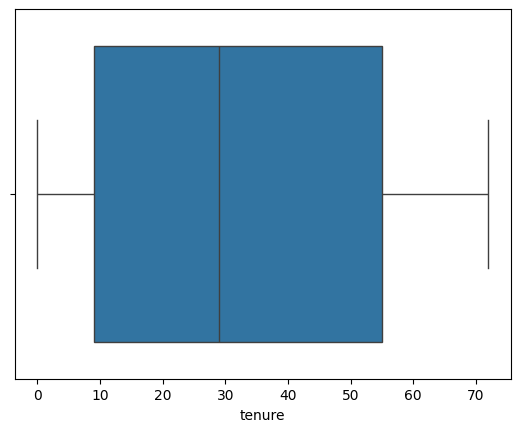

In [ ]:
#observing 'tenure' attribute
sns.boxplot(x='tenure',data=df)

<Axes: xlabel='MonthlyCharges'>

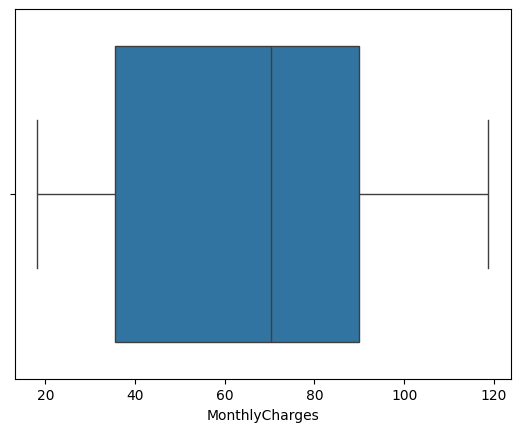

In [ ]:
sns.boxplot(x='MonthlyCharges',data=df)

Text(0.5, 1.0, 'Monthly Charges Distribution')

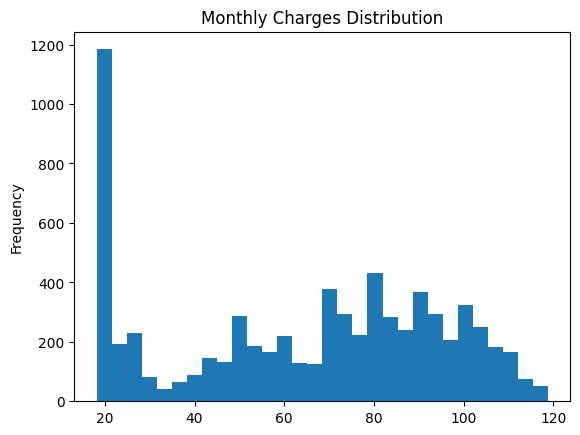

In [ ]:
plt.figure()
df['MonthlyCharges'].plot(kind='hist',bins=30)
plt.title('Monthly Charges Distribution')

Text(0.5, 1.0, 'Tenure Distribution')

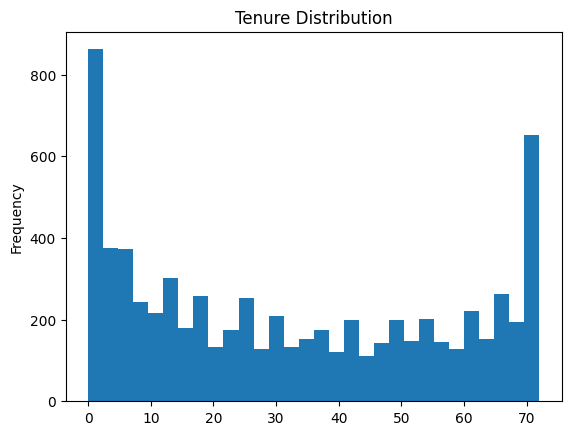

In [ ]:
plt.figure()
df['tenure'].plot(kind='hist',bins=30)
plt.title('Tenure Distribution')

Text(0.5, 1.0, 'Monthly Charges vs Churn')

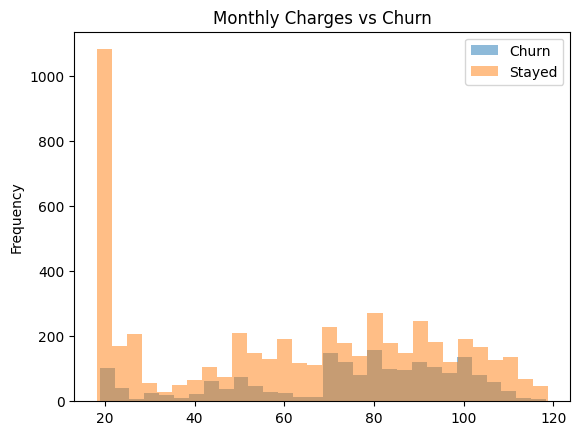

In [ ]:
plt.figure()

df[df['Churn']=='Yes']['MonthlyCharges'].plot(kind='hist',bins=30,alpha=0.5,label='Churn')
df[df['Churn']=='No']['MonthlyCharges'].plot(kind='hist',bins=30,alpha=0.5,label='Stayed')

plt.legend()
plt.title("Monthly Charges vs Churn")

Text(0.5, 1.0, 'Tenure vs Churn')

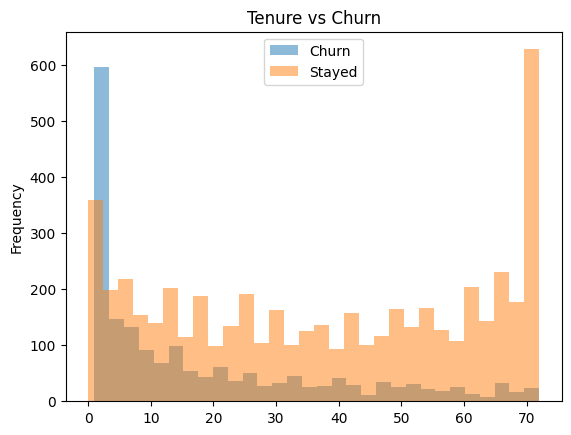

In [ ]:
plt.figure()

df[df['Churn']=='Yes']['tenure'].plot(kind='hist',bins=30,alpha=0.5,label='Churn')
df[df['Churn']=='No']['tenure'].plot(kind='hist',bins=30,alpha=0.5,label='Stayed')

plt.legend()
plt.title("Tenure vs Churn")

Text(0.5, 0.98, '')

<Figure size 640x480 with 0 Axes>

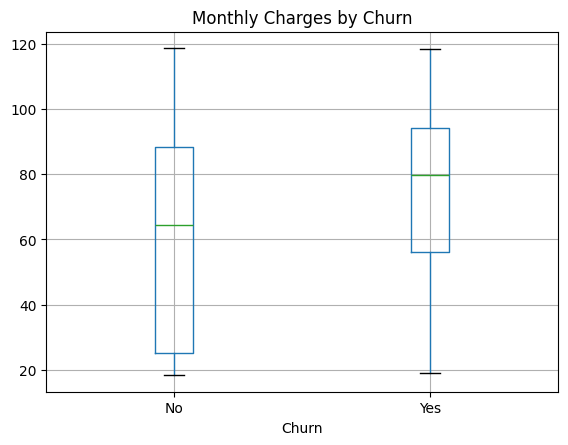

In [ ]:
plt.figure()
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title("Monthly Charges by Churn")
plt.suptitle("")

Text(0.5, 1.0, 'Correlation Matrix')

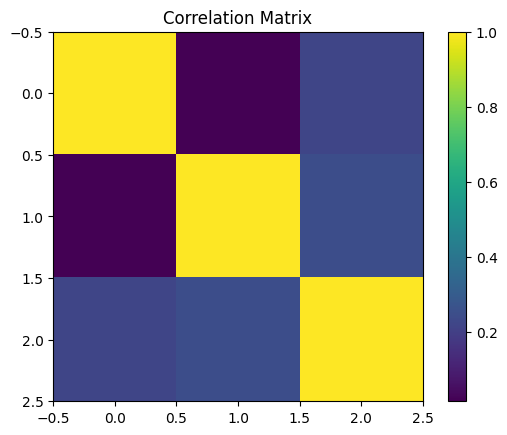

In [ ]:
import numpy as np
numeric_df=df.select_dtypes(include=np.number)

plt.figure()
plt.imshow(numeric_df.corr())
plt.colorbar()
plt.title("Correlation Matrix")

In [ ]:
for col in categorical_cols:
  churn_rate=df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean())
  print(churn_rate.sort_values(ascending=False))

customerID
0013-EXCHZ    1.0
0004-TLHLJ    1.0
9985-MWVIX    1.0
9986-BONCE    1.0
9992-RRAMN    1.0
             ... 
9950-MTGYX    0.0
9953-ZMKSM    0.0
9955-QOPOY    0.0
9957-YODKZ    0.0
9958-MEKUC    0.0
Name: Churn, Length: 7043, dtype: float64
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64
PhoneService
Yes    0.267096
No     0.249267
Name: Churn, dtype: float64
MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn, dtype: float64
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn, dtype: float64
OnlineBackup
No                     0.399288
Yes                    0.215315
No 

In [ ]:
## FEATURE ENGINEERING

services = [
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]
df['TotalServices']=df[services].apply(lambda x: (x=='Yes').sum(), axis=1)

In [ ]:
df['TotalServices']

,TotalServices
0,1
1,2
2,2
3,3
4,0
...,...
7038,5
7039,4
7040,1
7041,0


In [ ]:
#customer security score
security_services=['OnlineSecurity','OnlineBackup','DeviceProtection']

df['SecurityScore']=df[security_services].apply(lambda x: (x=='Yes').sum(),axis=1)

In [ ]:
df['SecurityScore']

,SecurityScore
0,1
1,2
2,2
3,2
4,0
...,...
7038,2
7039,2
7040,1
7041,0


In [ ]:
#Tenure Group
def tenure_group(t):
  if t<=12:
    return "New"
  elif t<=36:
    return "Mid"
  else:
    return "Loyal"
df['TenureGroup']=df['tenure'].apply(tenure_group)

In [ ]:
df['MonthlyChargeGroup'] = pd.qcut(df['MonthlyCharges'], 3, labels=['Low','Medium','High'])

In [ ]:
#Long Term Loyalty Score
contract_map={
    'Month-to-month':0,
    'One year':1,
    'Two year':2
}
df['ContractScore']=df['Contract'].map(contract_map)

In [ ]:
#The Usage of Automatic Payment
df['AutoPay']=df['PaymentMethod'].apply(lambda x: 1 if 'Credit card(automatic)' in x.lower() else 0)

In [ ]:
#Price Per Tenure
df['ChargePerMonthofTenure']=df['MonthlyCharges'] / (df['tenure']+1)

In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_469/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
binary_cols = [col for col in df.columns
               if df[col].dropna().isin(['Yes','No']).all()]

In [ ]:
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [ ]:
print(binary_cols)

['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


In [ ]:
df[binary_cols].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
df[binary_cols].isnull().sum()

,0
Partner,0
Dependents,0
PhoneService,0
PaperlessBilling,0
Churn,0


In [ ]:
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

In [ ]:
df['gender']

,gender
0,0
1,1
2,1
3,1
4,0
...,...
7038,1
7039,0
7040,0
7041,1


In [ ]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,TotalServices,SecurityScore,TenureGroup,MonthlyChargeGroup,ContractScore,AutoPay,ChargePerMonthofTenure
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,...,29.85,29.85,0,1,1,New,Low,0,0,14.925000
1,1,0,0,0,34,1,No,DSL,Yes,No,...,56.95,1889.50,0,2,2,Mid,Medium,1,0,1.627143
2,1,0,0,0,2,1,No,DSL,Yes,Yes,...,53.85,108.15,1,2,2,New,Medium,0,0,17.950000
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,...,42.30,1840.75,0,3,2,Loyal,Low,1,0,0.919565
4,0,0,0,0,2,1,No,Fiber optic,No,No,...,70.70,151.65,1,0,0,New,Medium,0,0,23.566667
5,0,0,0,0,8,1,Yes,Fiber optic,No,No,...,99.65,820.50,1,3,1,New,High,0,0,11.072222
6,1,0,0,1,22,1,Yes,Fiber optic,No,Yes,...,89.10,1949.40,0,2,1,Mid,High,0,0,3.873913
7,0,0,0,0,10,0,No phone service,DSL,Yes,No,...,29.75,301.90,0,1,1,New,Low,0,0,2.704545
8,0,0,1,0,28,1,Yes,Fiber optic,No,No,...,104.80,3046.05,1,4,1,Mid,High,0,0,3.613793
9,1,0,0,1,62,1,No,DSL,Yes,Yes,...,56.15,3487.95,0,2,2,Loyal,Medium,1,0,0.891270


In [ ]:
df = pd.get_dummies(df, columns=[
    'InternetService',
    'Contract',
    'PaymentMethod',
    'TenureGroup',
    'MonthlyChargeGroup'
], drop_first=True)

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numeric_cols=['tenure','MonthlyCharges','TotalCharges','TotalServices','SecurityScore']
X[numeric_cols]=scaler.fit_transform(X[numeric_cols])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.select_dtypes(include='object').columns

Index(['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies'],
      dtype='object')

In [ ]:
#encoding the categorical columns
cat_cols=X.select_dtypes(include='object').columns

In [ ]:
X=pd.get_dummies(X,columns=cat_cols,drop_first=True)

In [ ]:
X=pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
ChargePerMonthofTenure,0.169466
TotalCharges,0.126923
MonthlyCharges,0.123626
tenure,0.093695
ContractScore,0.064317
PaymentMethod_Electronic check,0.029460
TotalServices,0.028887
InternetService_Fiber optic,0.026123
SecurityScore,0.022753
gender,0.022593


In [ ]:
#baseline model: Logistic Regression
from sklearn.linear_model import LogisticRegression
model_lr=LogisticRegression(max_iter=1000)
model_lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#cross-validation
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(model_lr,X_train, y_train, cv=5, scoring='f1')
print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

CV F1 Scores: [0.63079777 0.58188825 0.56332703 0.57809695 0.544     ]
Mean CV F1: 0.5796220000709043


In [ ]:
y_pred=model_lr.predict(X_test)

In [ ]:
#Model evalution
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print("Accuracy Score:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy Score: 0.8097941802696949
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



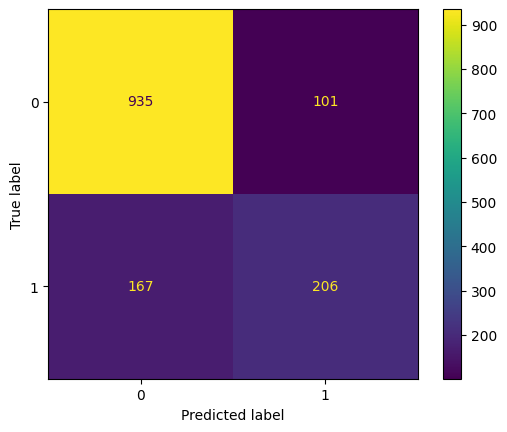

In [ ]:
from sklearn.metrics  import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model_lr, X_test,y_test)

In [ ]:
#model coefficient analysis
import pandas as pd
coefficients=pd.Series(model_lr.coef_[0], index=X.columns)
coefficients.sort_values(ascending=False).head(10)

,0
InternetService_Fiber optic,1.047802
MultipleLines_Yes,0.396391
PaperlessBilling,0.339717
TotalCharges,0.324043
StreamingMovies_Yes,0.302055
PaymentMethod_Electronic check,0.262454
TotalServices,0.250716
StreamingTV_Yes,0.190363
SeniorCitizen,0.184567
Partner,0.088312


In [ ]:
## model performance improvement
# threshold tuning
y_probs=model_lr.predict_proba(X_test)[:,1]
y_pred_new=(y_probs>0.3).astype(int)

In [ ]:
#class imbalance düzeltme
model_lr=LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
#cross-validation
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(model_lr,X_train, y_train, cv=5, scoring='f1')
print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

CV F1 Scores: [0.64705882 0.61822985 0.62077922 0.61082474 0.61049724]
Mean CV F1: 0.6214779757670598


In [ ]:
y_pred=model_lr.predict(X_test)

In [ ]:
#Model evalution
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print("Accuracy Score:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy Score: 0.7643718949609652
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.76      0.78      1409



In [ ]:
# Trying other machine learning models for better results and performance
#RandomForest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(class_weight='balanced')
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced')

In [ ]:
#cross-validation
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(rf,X_train, y_train, cv=5, scoring='f1')
print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

CV F1 Scores: [0.58736059 0.54545455 0.52408478 0.53612167 0.5029703 ]
Mean CV F1: 0.5391983777407255


In [ ]:
y_probs=rf.predict_proba(X_test)[:,1]
y_pred_new=(y_probs>0.3).astype(int)

In [ ]:
rf=RandomForestClassifier(class_weight='balanced')
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced')

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(model_lr,X_train, y_train, cv=5, scoring='f1')
print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

CV F1 Scores: [0.64705882 0.61822985 0.62077922 0.61082474 0.61049724]
Mean CV F1: 0.6214779757670598


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print("Accuracy Score:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy Score: 0.7643718949609652
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.76      0.78      1409



In [ ]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=3)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_probs=xgb.predict_proba(X_test)[:,1]
y_pred_new=(y_probs>0.3).astype(int)

In [ ]:
xgb=XGBClassifier(class_weight='balanced')
xgb.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:40:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(xgb,X_train, y_train, cv=5, scoring='f1')
print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:40:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:40:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:40:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:40:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CV F1 Scores: [0.60240964 0.54014599 0.54092527 0.5528169  0.53283302]
Mean CV F1: 0.5538261625811881


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:40:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print("Accuracy Score:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy Score: 0.7643718949609652
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.76      0.78      1409

